In [1]:
# Cell 1 — Installs
!pip install pandas numpy scikit-learn --quiet

In [3]:
!pip install pandas


In [6]:
import sys
!{sys.executable} -m pip install pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 2.1 MB/s  0:00:06a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 2.8 MB/s  0:00:06a 0:00:010:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pandas]━━━━ 3/4 [pandas]


In [8]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 3.2 MB/s  0:00:03m 3.6 MB/s eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 3.0 MB/s  0:00:12 eta 0:00:010:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]


In [9]:
# Cell 2 — Imports
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from shared.config import (DATA_PATH, CHUNK_SIZE, RANDOM_STATE,
                            OUTPUT_DIR, MODEL_DIR)
print("Imports OK")

Config loaded successfully
Imports OK


In [10]:
# Cell 3 — Load dataset in chunks
print("Loading CICIDS2018 dataset...")
chunks = []

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE,
                          engine="python",
                          on_bad_lines="skip"):
    chunk["Label_Binary"] = chunk["label"].apply(
        lambda x: 0 if str(x).lower() == "benign" else 1
    )
    chunks.append(chunk)

df_full = pd.concat(chunks, ignore_index=True)
del chunks

print(f"Shape       : {df_full.shape}")
print(f"Class dist  :\n{df_full['Label_Binary'].value_counts()}")
print(f"Benign ratio: "
      f"{(df_full['Label_Binary']==0).mean()*100:.1f}%")
print(f"Attack ratio: "
      f"{(df_full['Label_Binary']==1).mean()*100:.1f}%")

Loading CICIDS2018 dataset...
Shape       : (8284254, 81)
Class dist  :
Label_Binary
0    6112151
1    2172103
Name: count, dtype: int64
Benign ratio: 73.8%
Attack ratio: 26.2%


In [11]:
# Cell 4 — Feature engineering + cleaning
X_full = df_full.drop(["label", "Label_Binary"], axis=1)
y_full = df_full["Label_Binary"]

# Numeric conversion
X_full = X_full.apply(pd.to_numeric, errors="coerce")

# Remove infinite and null values (IEEE standard preprocessing)
X_full = X_full.replace([np.inf, -np.inf], np.nan)

# Drop columns with all NaN
cols_before = X_full.shape[1]
X_full = X_full.dropna(axis=1, how="all")
print(f"Dropped {cols_before - X_full.shape[1]} all-NaN columns")

# Fill remaining NaN with median (robust to outliers)
X_full = X_full.fillna(X_full.median())

# Memory optimization
X_full = X_full.astype("float32")

print(f"Final features shape : {X_full.shape}")
print(f"Memory usage         : "
      f"{X_full.memory_usage().sum() / 1e9:.2f} GB")

Dropped 1 all-NaN columns
Final features shape : (8284254, 78)
Memory usage         : 2.58 GB


In [12]:
# Cell 5 — 70/15/15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y_full,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_full
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train : {X_train.shape} | "
      f"Attack ratio: "
      f"{y_train.mean()*100:.1f}%")
print(f"Val   : {X_val.shape}   | "
      f"Attack ratio: "
      f"{y_val.mean()*100:.1f}%")
print(f"Test  : {X_test.shape}  | "
      f"Attack ratio: "
      f"{y_test.mean()*100:.1f}%")

Train : (5798977, 78) | Attack ratio: 26.2%
Val   : (1242638, 78)   | Attack ratio: 26.2%
Test  : (1242639, 78)  | Attack ratio: 26.2%


In [13]:
# Cell 6 — Save splits for all other notebooks
splits = {
    "X_train": X_train,
    "X_val"  : X_val,
    "X_test" : X_test,
    "y_train": y_train,
    "y_val"  : y_val,
    "y_test" : y_test,
}

with open("models/splits.pkl", "wb") as f:
    pickle.dump(splits, f)

print("Splits saved to models/splits.pkl")
print("Notebook 01 complete — proceed to 02_ml_models.ipynb")

Splits saved to models/splits.pkl
Notebook 01 complete — proceed to 02_ml_models.ipynb


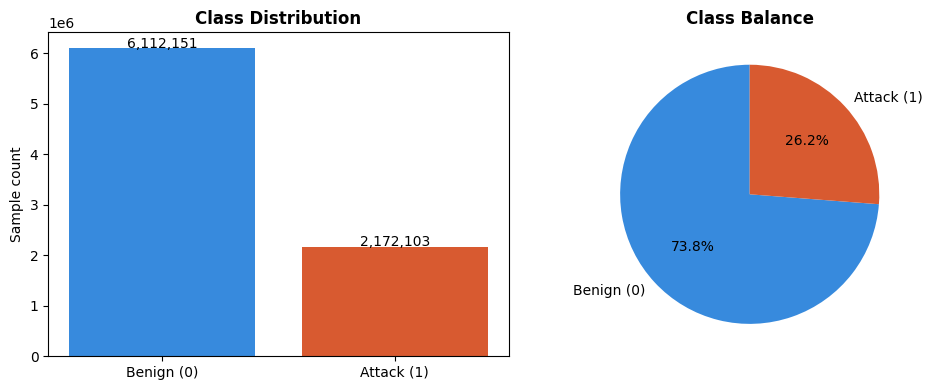

In [19]:
# Cell 7 — Class distribution plot
import matplotlib.pyplot as plt

labels = ["Benign (0)", "Attack (1)"]
counts = [int((y_full == 0).sum()), int((y_full == 1).sum())]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, counts, color=["#378ADD", "#D85A30"])
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Sample count")
for i, c in enumerate(counts):
    axes[0].text(i, c + 5000, f"{c:,}", ha="center")

axes[1].pie(counts, labels=labels,
            colors=["#378ADD", "#D85A30"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Balance", fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/graphs/01_class_distribution.png", dpi=150)
plt.show()

In [15]:
!pip install matplotlib


In [18]:

import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 3.8 MB/s  0:00:023.7 MB/s eta 0:00:01:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 2.9 MB/s  0:00:01m 2.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.7 MB/s  0:00:003.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 3.2 MB/s  0:00:023.2 MB/s eta 0:00:01:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]
